In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.manifolds.euclidean.vector.pullback.standard.banana import BananaStandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.standard import StandardVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.k_fold import KfoldVectorRiemannianAutoencoder

# manual seed
torch.manual_seed(31)

In [ ]:
vector_euclidean = BananaStandardPullbackVectorEuclidean(shear=0.1, offset=2.0)

base_point = torch.zeros((2,)) # shape (2,)
tangent_basis = F.normalize(torch.randn((2,)), dim=0)[None]  # shape (1, 2)

standard_rae = StandardVectorRiemannianAutoencoder(vector_euclidean, base_point, tangent_basis)
kfold_rae = KfoldVectorRiemannianAutoencoder(vector_euclidean, base_point, tangent_basis, K=5)

In [ ]:
# project some data on the manifold
data = torch.randn((100, 2)) * 4.0

# standard RAE
rae_projected_data = standard_rae.project_on_manifold(data)
rae_rmse = torch.sqrt(torch.mean((rae_projected_data - data) ** 2))

# k-fold RAE
kfold_rae_projected_data = kfold_rae.project_on_manifold(data)
kfold_rae_rmse = torch.sqrt(torch.mean((kfold_rae_projected_data - data) ** 2))

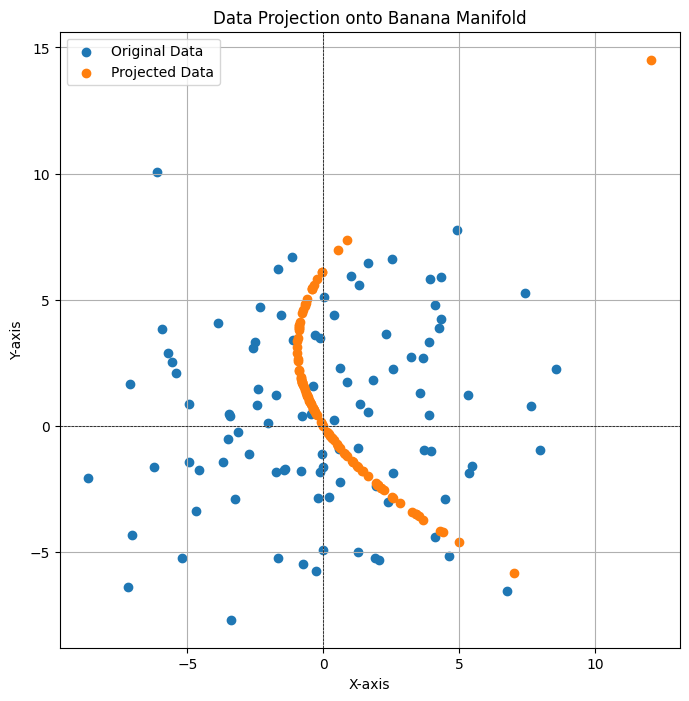

In [ ]:
# plot results
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], label='Original Data')
plt.scatter(rae_projected_data[:, 0], rae_projected_data[:, 1], label='Standard RAE Projected Data')
# plt.scatter(kfold_rae_projected_data[:, 0], kfold_rae_projected_data[:, 1], label='K-Fold RAE Projected Data')
plt.title('Data Projection onto Banana Manifold')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid()
plt.legend()
plt.show()